In [1]:
import os
import glob
import pickle
import itertools

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [2]:
lgn_shapes = [32, 64, 128, 256, 512, 1024]

## the untrained model
Just uses the base initialized model with probabilistic connections between LGN and V1

In [21]:
model_files = glob.glob("/u/home/s/skirti/dipoppa-lab/dipoppa-lab/thalamocortical-expansion/02_code/thalamocortical_powerlaw/results_ringach_grid_probabilistic/*.pkl")
metrics = ["v1_gini", "test_viol", "test_loss"]
models = []

for file in model_files:
    with open(file, 'rb') as f:
        models.append(pickle.load(f))

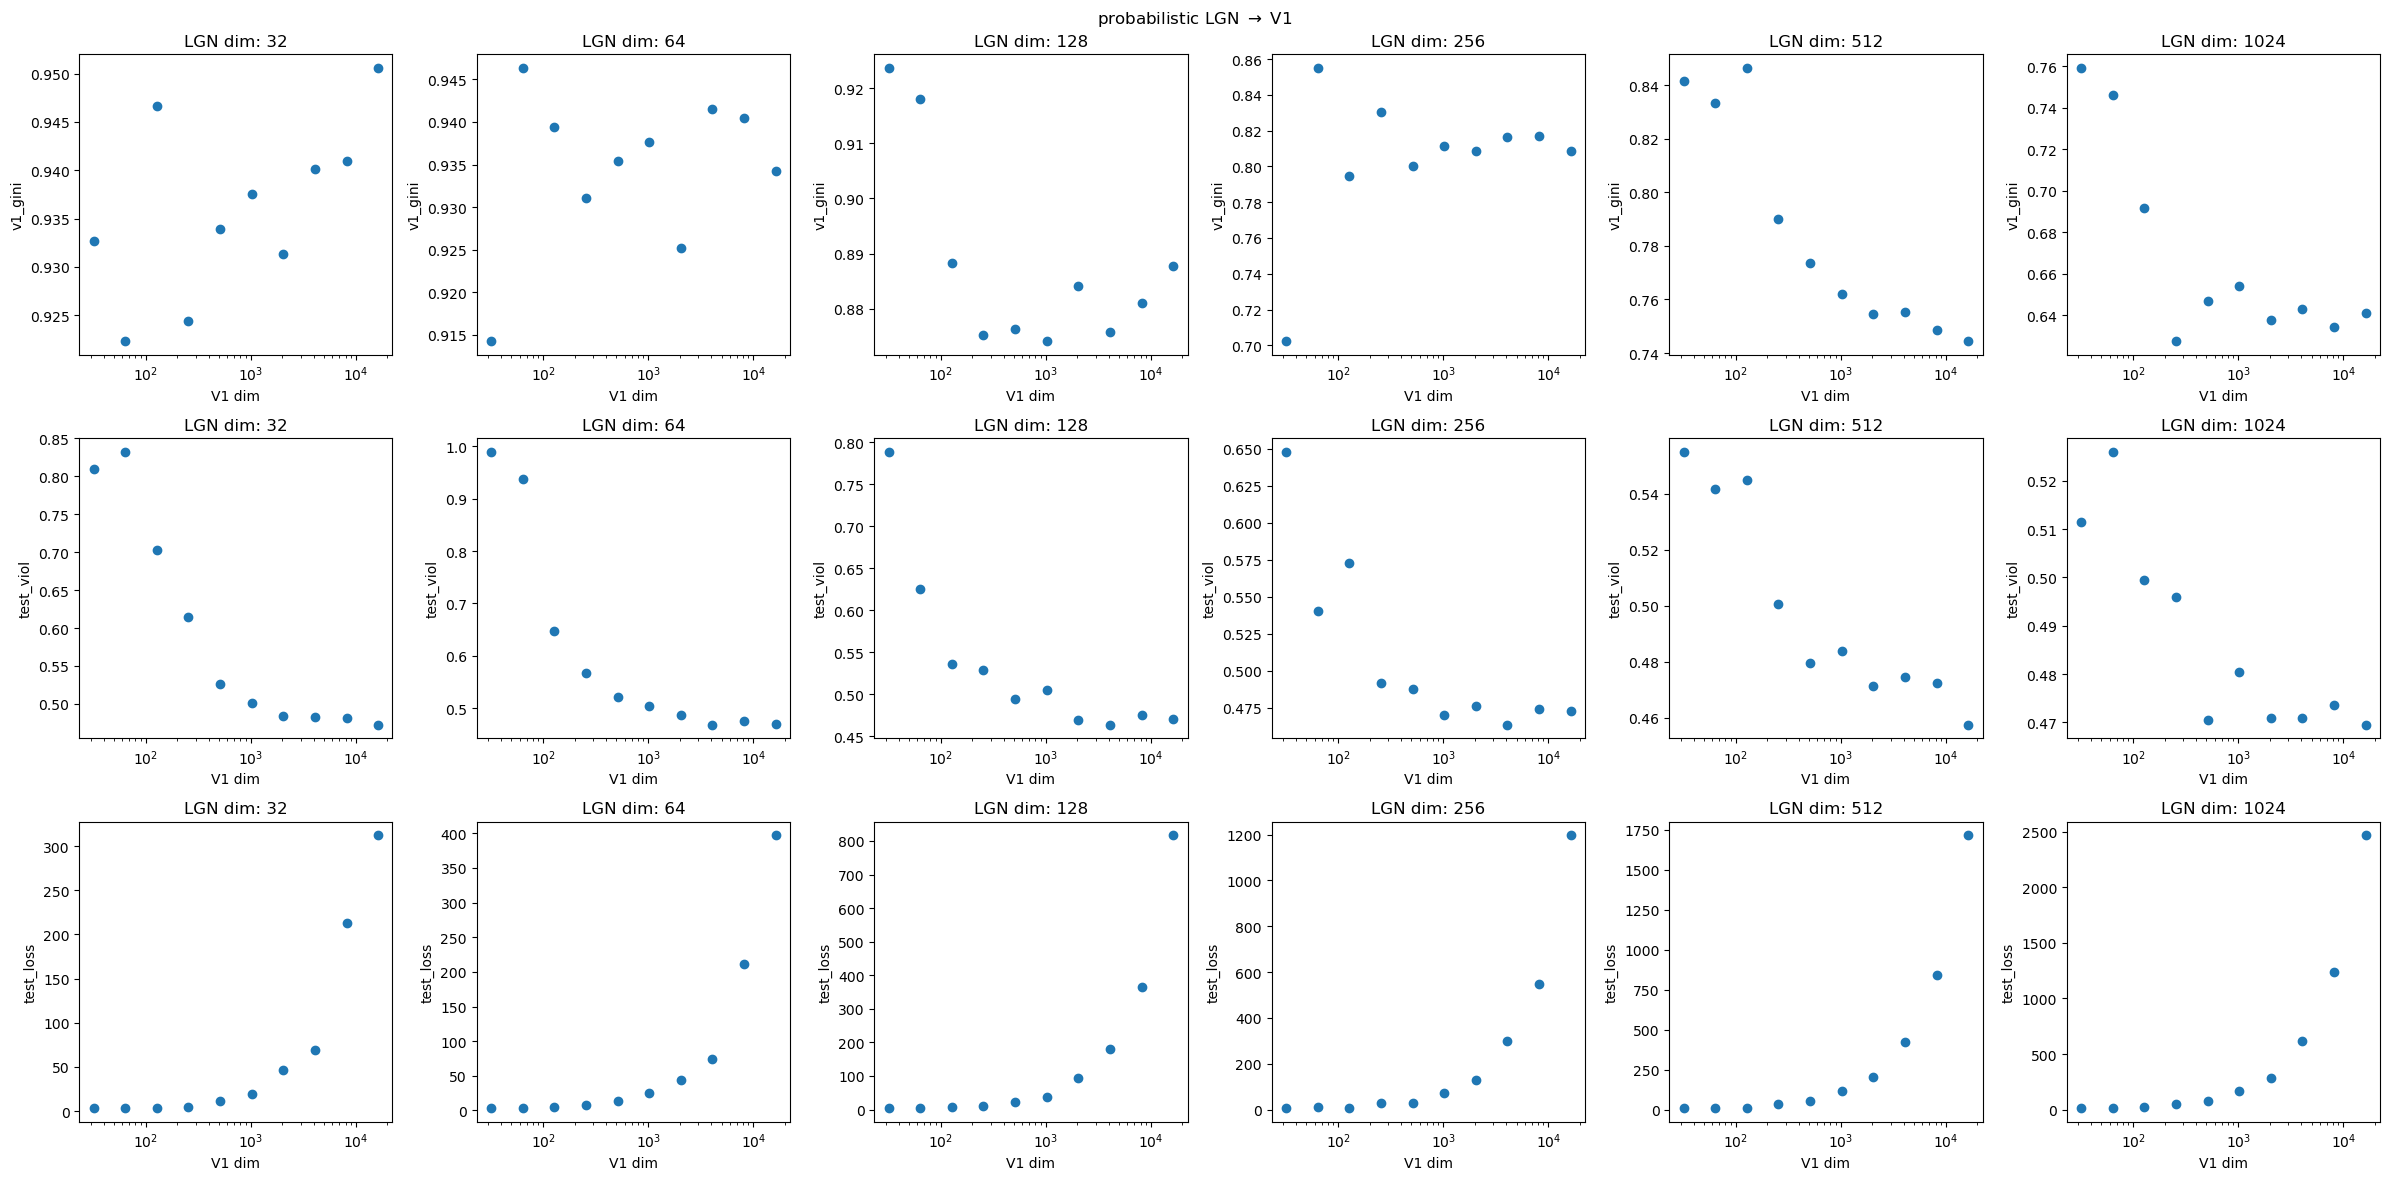

In [22]:
fig, ax = plt.subplots(3, 6, figsize=(24, 12))

for j,m in enumerate(metrics):
    for i_col in range(6):
        
        # plot the right data
        model_spec = [m for m in models if m["lgn_params"] == lgn_shapes[i_col]]
        ax[j][i_col].scatter([ms["v1_params"] for ms in model_spec], [np.abs(ms[m]) for ms in model_spec])
        
        # add the labels
        ax[j][i_col].set_title(f"LGN dim: {lgn_shapes[i_col]}")
        ax[j][i_col].set_xscale("log")
        ax[j][i_col].set_xlabel("V1 dim")
        ax[j][i_col].set_ylabel(m)
        
fig.suptitle(r"probabilistic LGN $\to$ V1")
fig.set_tight_layout(True)
plt.show()

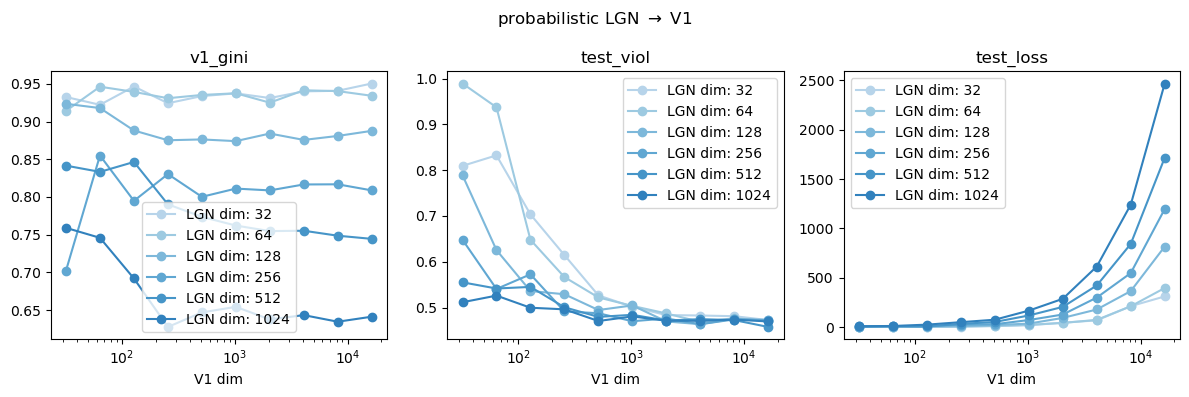

In [34]:
# let's plot each metric on a single plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
blues = cm.Blues(np.linspace(0.3, 1, 10))

for i,m in enumerate(metrics):
    for j,lgn in enumerate(lgn_shapes):

        model_spec = [m for m in models if m["lgn_params"] == lgn]
        v1_dim, metric = zip(*sorted(zip([ms["v1_params"] for ms in model_spec], [np.abs(ms[m]) for ms in model_spec])))
        ax[i].plot(v1_dim, metric, c=blues[j], label=f"LGN dim: {lgn}", marker="o")
        
        ax[i].set_xscale("log")
        ax[i].set_title(m)
        ax[i].set_xlabel("V1 dim")
        ax[i].legend()
        
fig.suptitle(r"probabilistic LGN $\to$ V1")
fig.set_tight_layout(True)
plt.show()

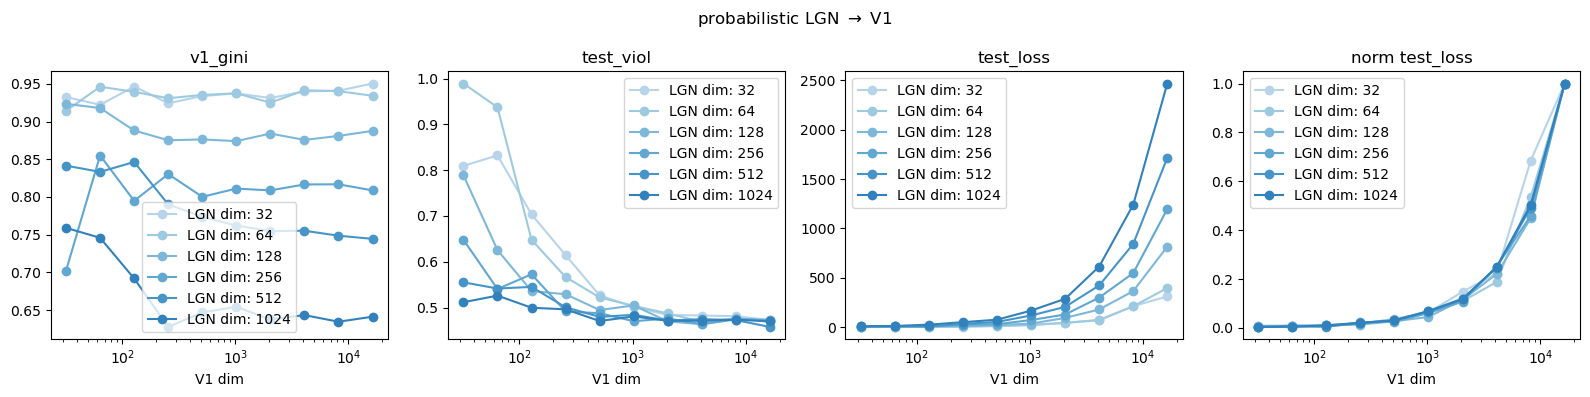

In [31]:
# let's plot each metric on a single plot
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
blues = cm.Blues(np.linspace(0.3, 1, 10))

for i,m in enumerate(metrics):
    for j,lgn in enumerate(lgn_shapes):

        model_spec = [m for m in models if m["lgn_params"] == lgn]
        v1_dim, metric = zip(*sorted(zip([ms["v1_params"] for ms in model_spec], [np.abs(ms[m]) for ms in model_spec])))
        ax[i].plot(v1_dim, metric, c=blues[j], label=f"LGN dim: {lgn}", marker="o")
        
        ax[i].set_xscale("log")
        ax[i].set_title(m)
        ax[i].set_xlabel("V1 dim")
        ax[i].legend()
        
        # let's just add a check for the normalized test_loss
        if m == "test_loss":
            metric /= np.max(metric)
            
            ax[3].plot(v1_dim, metric, c=blues[j], label=f"LGN dim: {lgn}", marker="o")
        
            ax[3].set_xscale("log")
            ax[3].set_title("norm test_loss")
            ax[3].set_xlabel("V1 dim")
            ax[3].legend()
        
fig.suptitle(r"probabilistic LGN $\to$ V1")
fig.set_tight_layout(True)
plt.show()

## unconstrained trained model
allowing the LGN-V1 weights to be entirely optimized over

In [4]:
model_files = glob.glob("/u/home/s/skirti/dipoppa-lab/dipoppa-lab/thalamocortical-expansion/02_code/thalamocortical_powerlaw/results_ringach_grid_unconstrained/*.pkl")
metrics = ["v1_gini", "test_viol", "test_loss"]
models = []

for file in model_files:
    with open(file, 'rb') as f:
        models.append(pickle.load(f))

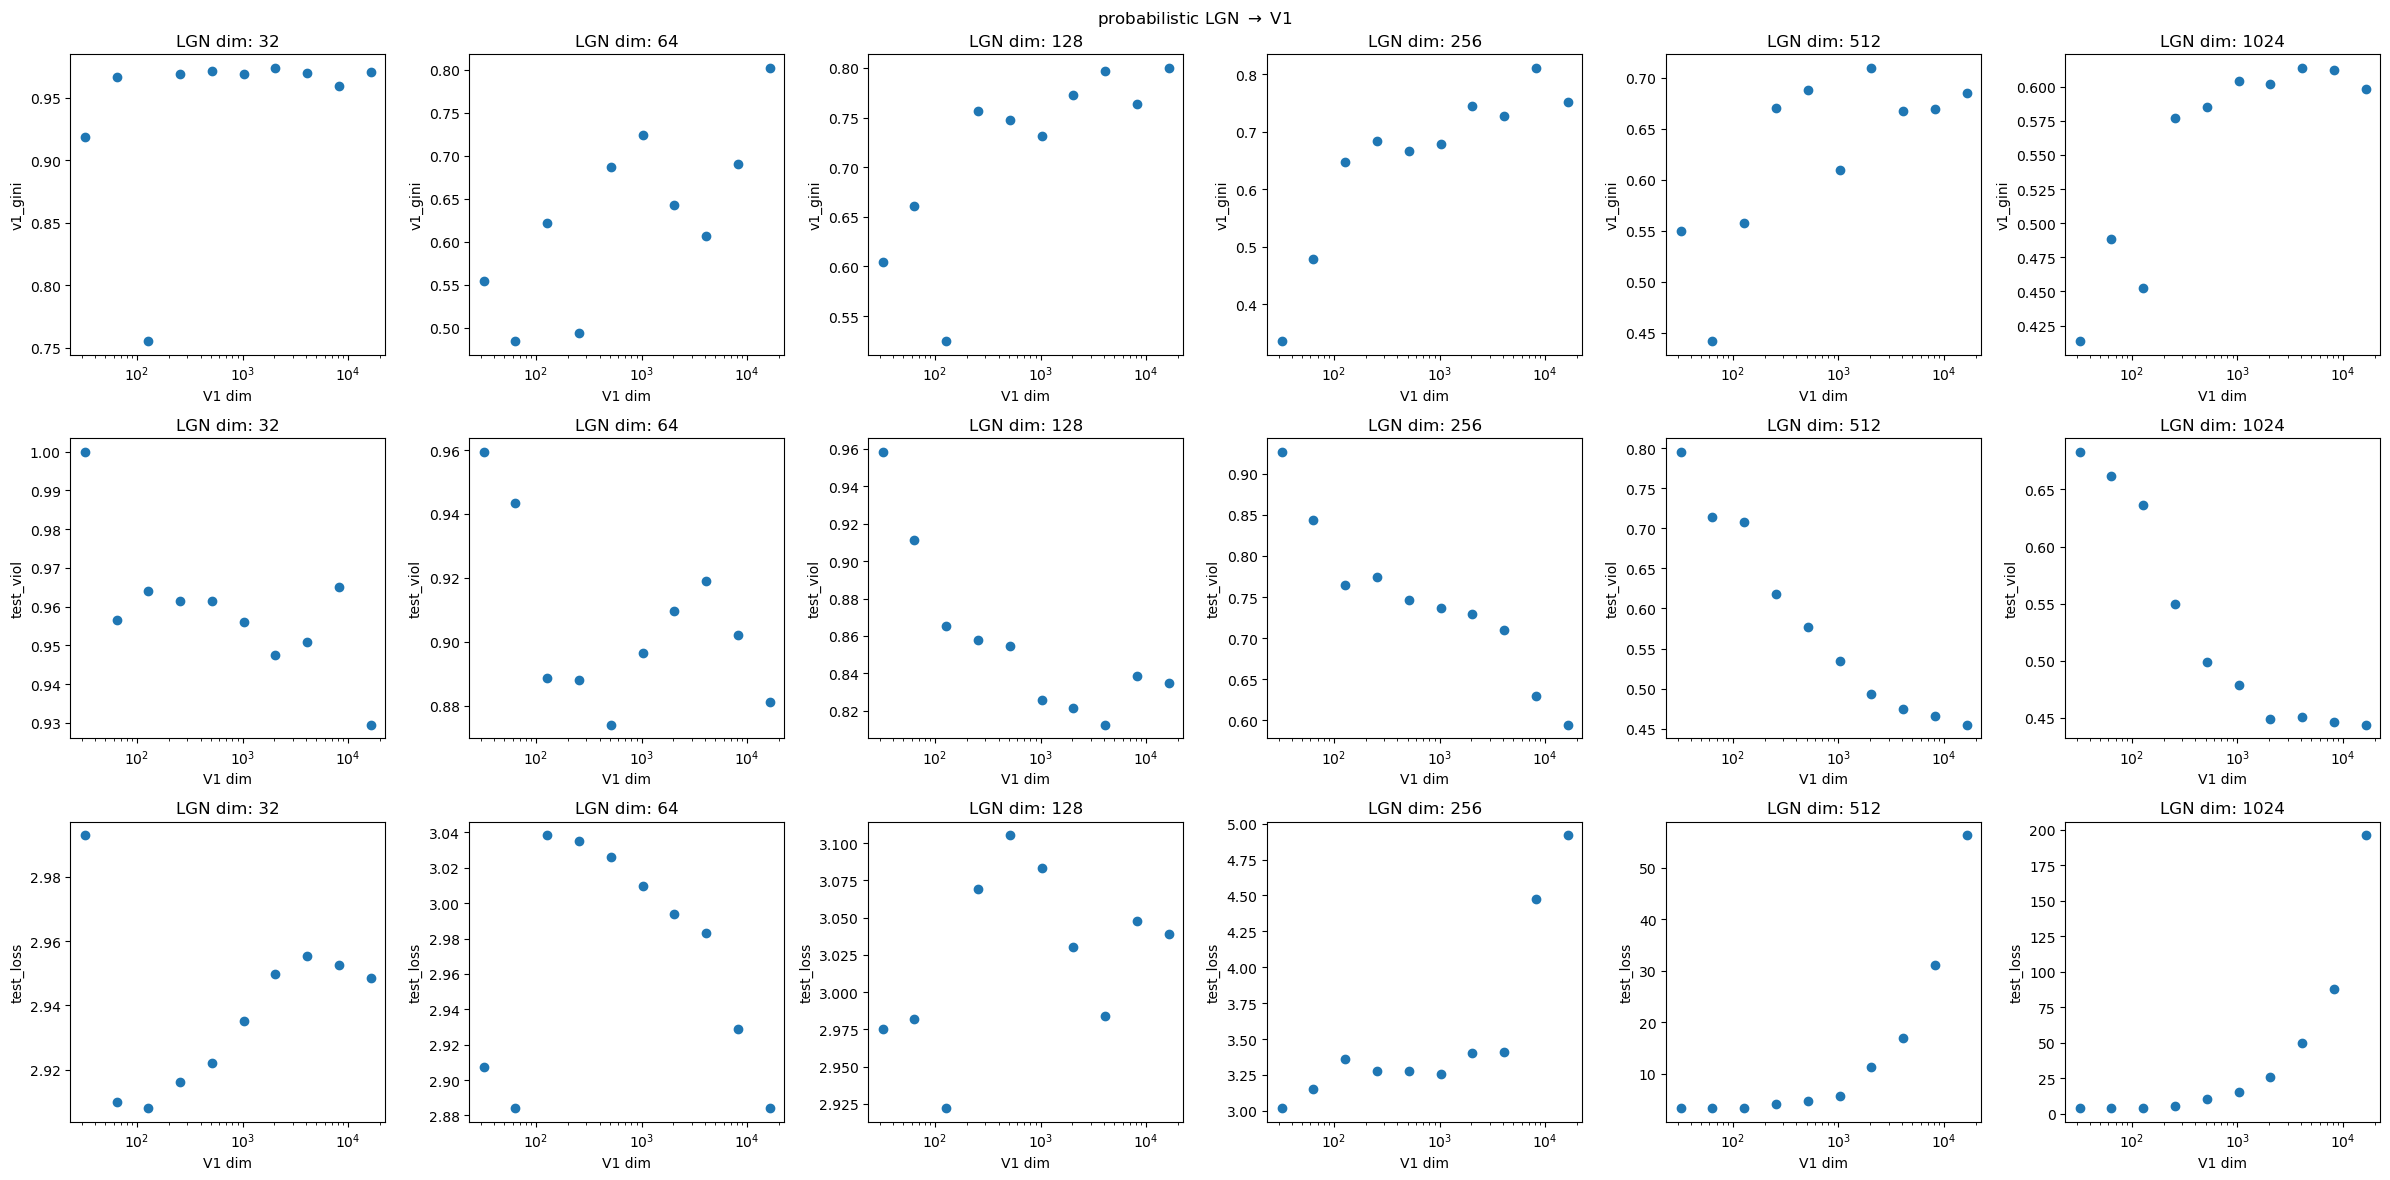

In [5]:
fig, ax = plt.subplots(3, 6, figsize=(24, 12))

for j,m in enumerate(metrics):
    for i_col in range(6):
        
        # plot the right data
        model_spec = [m for m in models if m["lgn_params"] == lgn_shapes[i_col]]
        ax[j][i_col].scatter([ms["v1_params"] for ms in model_spec], [np.abs(ms[m]) for ms in model_spec])
        
        # add the labels
        ax[j][i_col].set_title(f"LGN dim: {lgn_shapes[i_col]}")
        ax[j][i_col].set_xscale("log")
        ax[j][i_col].set_xlabel("V1 dim")
        ax[j][i_col].set_ylabel(m)
        
fig.suptitle(r"probabilistic LGN $\to$ V1")
fig.set_tight_layout(True)
plt.show()

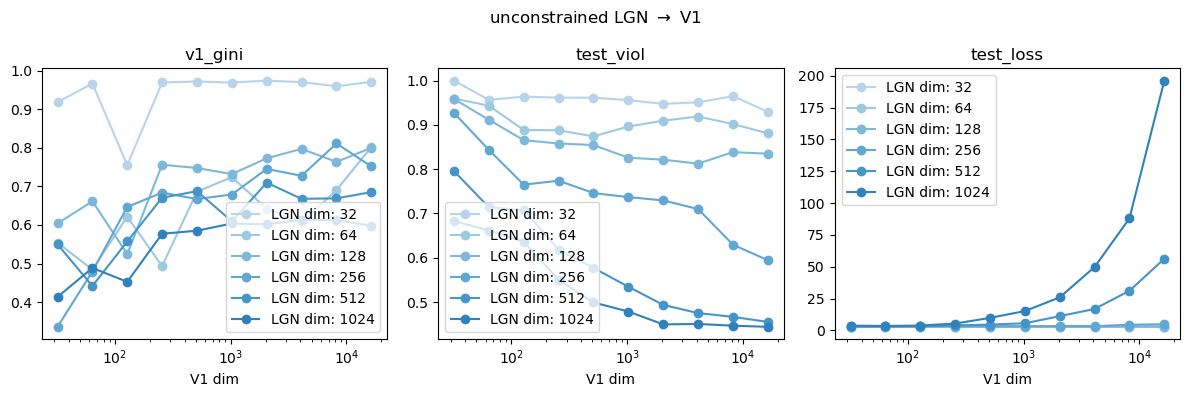

In [7]:
# let's plot each metric on a single plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
blues = cm.Blues(np.linspace(0.3, 1, 10))

for i,m in enumerate(metrics):
    for j,lgn in enumerate(lgn_shapes):

        model_spec = [m for m in models if m["lgn_params"] == lgn]
        v1_dim, metric = zip(*sorted(zip([ms["v1_params"] for ms in model_spec], [np.abs(ms[m]) for ms in model_spec])))
        ax[i].plot(v1_dim, metric, c=blues[j], label=f"LGN dim: {lgn}", marker="o")
        
        ax[i].set_xscale("log")
        ax[i].set_title(m)
        ax[i].set_xlabel("V1 dim")
        ax[i].legend()
        
fig.suptitle(r"unconstrained LGN $\to$ V1")
fig.set_tight_layout(True)
plt.show()

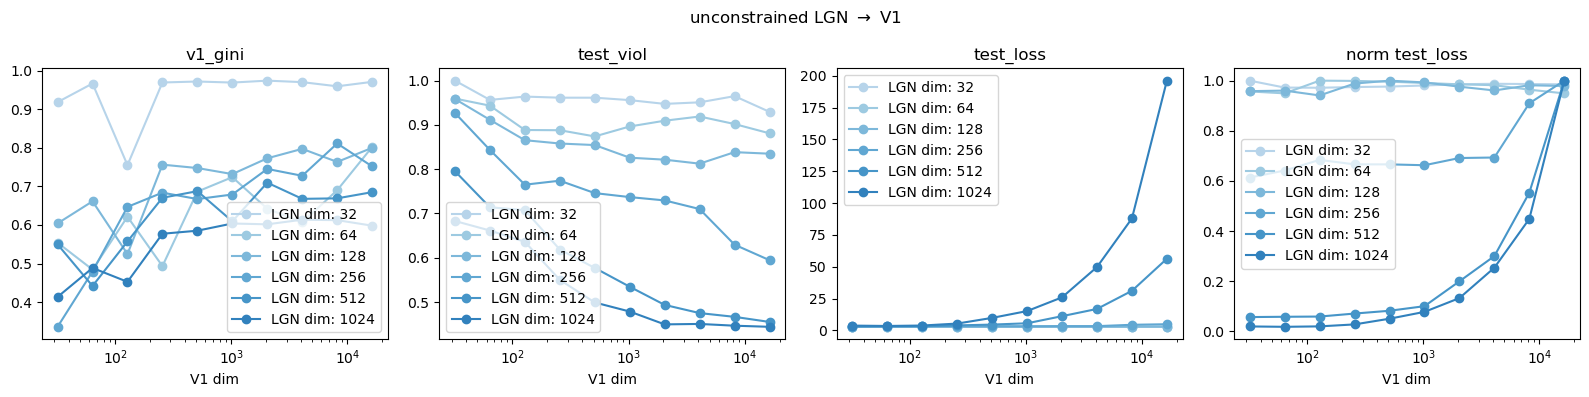

In [9]:
# let's plot each metric on a single plot
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
blues = cm.Blues(np.linspace(0.3, 1, 10))

for i,m in enumerate(metrics):
    for j,lgn in enumerate(lgn_shapes):

        model_spec = [m for m in models if m["lgn_params"] == lgn]
        v1_dim, metric = zip(*sorted(zip([ms["v1_params"] for ms in model_spec], [np.abs(ms[m]) for ms in model_spec])))
        ax[i].plot(v1_dim, metric, c=blues[j], label=f"LGN dim: {lgn}", marker="o")
        
        ax[i].set_xscale("log")
        ax[i].set_title(m)
        ax[i].set_xlabel("V1 dim")
        ax[i].legend()
        
        # let's just add a check for the normalized test_loss
        if m == "test_loss":
            metric /= np.max(metric)
            
            ax[3].plot(v1_dim, metric, c=blues[j], label=f"LGN dim: {lgn}", marker="o")
        
            ax[3].set_xscale("log")
            ax[3].set_title("norm test_loss")
            ax[3].set_xlabel("V1 dim")
            ax[3].legend()
        
fig.suptitle(r"unconstrained LGN $\to$ V1")
fig.set_tight_layout(True)
plt.show()

In [10]:
model_history_files = glob.glob("/u/home/s/skirti/dipoppa-lab/dipoppa-lab/thalamocortical-expansion/02_code/thalamocortical_powerlaw/results_ringach_grid_unconstrained/train_history*.pkl")
model_histories = []

for file in model_files:
    with open(file, 'rb') as f:
        model_histories.append(pickle.load(f))

In [12]:
# sort the histories so they show up in order for plotting
model_histories = sorted(model_histories, key=lambda x: (x['lgn_params'], x['v1_params']))

In [14]:
model_histories[0].keys()

dict_keys(['lgn_params', 'v1_params', 'batch_size', 'margin', 'l1_lambda', 'init_time', 'run_time', 'n_triplets', 'rgc_shape', 'lgn_shape', 'v1_shape', 'v1_gini', 'test_loss', 'test_viol', 'rgc_out', 'lgn_out', 'v1_out'])

In [ ]:
v1_shapes = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]

fig, ax = plt.subplots(6, 10, figsize=(24, 40))

for i,l in enumerate(lgn_shapes):
    for j,v in enumerate(v1_shapes):
        
        # plot the violations/loss over training
        ax[i][j].plot(model_histories[i*j])

## constrained trained model
here we add a penalty for weights connecting LGN to V1 cells based on their distance, a sort of optimization that favors closer connections